
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://imgtr.ee/images/2023/06/20/ZrpSs.png" >
      </a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [23]:
mnist = fetch_openml('mnist_784', as_frame=False)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning:

The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.



**You can also get the data from kaggle** : [Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer/data)

In [24]:
X = mnist.data
y = mnist.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state=0)

print('Traning data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Traning data shape: (52500, 784)
Testing data shape: (17500, 784)


In [25]:
classes = np.unique(y_train)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [26]:
img = X_train[4].reshape((28,28))
fig = px.imshow(img, width=400, height=400)
fig.show()

# Applying ML Model Without PCA

In [27]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train,y_train)

print('Accuracy on Test set: {:.3f}'.format(tree.score(X_test,y_test)))

Accuracy on Test set: 0.867


# Apply PCA with 10 components

In [28]:
pca_10 = PCA(n_components=10)
X_train_10 = pca_10.fit_transform(X_train)
X_test_10 = pca_10.transform(X_test)

# Apply model with PCA 10 components

In [29]:
tree_10 = DecisionTreeClassifier(random_state=0)
tree_10.fit(X_train_10,y_train)

print('Accuracy on Test set: {:.3f}'.format(tree_10.score(X_test_10,y_test)))

Accuracy on Test set: 0.825


# Apply ML model with PCA 2 components

In [30]:
pca_2 = PCA(n_components=2)
X_train_2 = pca_2.fit_transform(X_train)
X_test_2 = pca_2.transform(X_test)

In [31]:
df_train_2 = pd.DataFrame(data = X_train_2, columns = ['PCA' + str(i+1) for i in range(2)])

In [32]:
df_train_2['target'] = y_train

In [33]:
df_train_2

,PCA1,PCA2,target
0,-199.076529,473.067762,2
1,-844.030127,412.357017,1
2,401.406339,225.895295,2
3,21.901652,-535.771551,7
4,160.768200,-694.867964,7
...,...,...,...
52495,-628.206026,550.651307,1
52496,75.260162,-629.599304,4
52497,931.664015,-91.245980,6
52498,58.756533,-77.036909,5


In [34]:
fig = px.scatter(df_train_2, x="PCA1", y="PCA2", color="target", width=800, height=700, opacity=0.7)
fig.show()

In [35]:
tree_2 = DecisionTreeClassifier(random_state=0)
tree_2.fit(X_train_2,y_train)

print('Accuracy on Test set: {:.3f}'.format(tree_2.score(X_test_2,y_test)))

Accuracy on Test set: 0.376


# PCA for 90% variance

In [36]:
pca = PCA(n_components=0.9)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [37]:
pca.n_components_ # this number of components will achive a good results

87

In [38]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train_pca,y_train)

print('Accuracy on Test set: {:.3f}'.format(tree.score(X_test_pca,y_test)))

Accuracy on Test set: 0.840


# Best No. of Components (Elbow Method)

In [39]:
pca = PCA(n_components=784)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train_pca,y_train)

print('Accuracy on Test set: {:.3f}'.format(tree.score(X_test_pca,y_test)))
px.area( x = range(1, pca.n_components_ + 1), y = pca.explained_variance_ratio_.cumsum())

Accuracy on Test set: 0.813


# Complete Pipeline

**Note: Grid Search is killer 😔**

In [40]:
# scaler = StandardScaler()
# pca = PCA()
# tree = DecisionTreeClassifier(random_state=0)

# pipe = Pipeline(steps=[('scaler', scaler), ('pca', pca), ('tree', tree)])

# param_grid = {
#     'pca__n_components': [0.7, 0.8, 0.9],
#     'tree__max_depth': [8, 10, 12]
# }

# search = GridSearchCV(pipe, param_grid, n_jobs=-1, cv=3)
# search.fit(X_train, y_train)

# print('Best Parameters:', search.best_params_)
# print('Testing Score:', search.score(X_test, y_test))

# Compare Original Image with Reconstructed Image

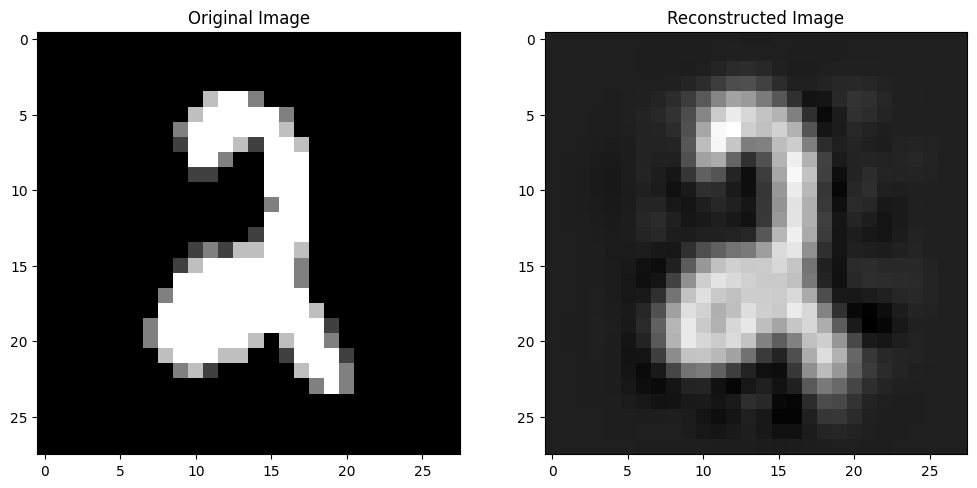

In [41]:
# compare original and reconstructed images
pca = PCA(n_components=87)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_inv = pca.inverse_transform(X_train_pca)
X_test_inv = pca.inverse_transform(X_test_pca)

fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(X_train_inv[0].reshape(28, 28), cmap='gray')
ax[1].set_title('Reconstructed Image');



# Task

Find the best no. of components with best model to get best accuracy